<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Exp%203%20-%20Polynomial%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Visualizing data**

**A linear relationship would mean:**


*   For every +1 level increase, salary would increase by roughly the same fixed amount.
*   This would appear as a straight diagonal line.



**In your plot:**


*   The green trend line curves upward — the rate of salary growth is not constant.

*   At low levels (1–4), salaries rise slowly.
*   At high levels (8–10), salaries jump by hundreds of thousands in just 1 level step.


*   This “curved” shape breaks the linearity assumption.










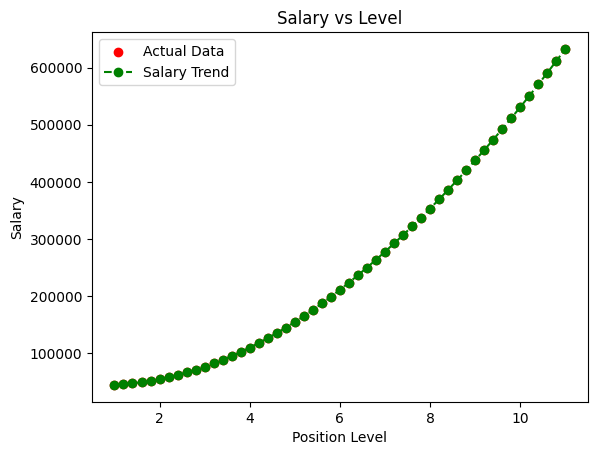

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
dataset = pd.read_csv('/content/Qwen_csv_20250817_bh3eply8h.txt')
X = dataset.iloc[:, 0].values  # Level
y = dataset.iloc[:, -1].values # Salary

# Sort data just in case (important for line plotting)
sorted_indices = np.argsort(X)
X = X[sorted_indices]
y = y[sorted_indices]

# Scatter plot of actual data
plt.scatter(X, y, color='red', label='Actual Data')

# Smooth curve connecting the points
plt.plot(X, y, color='green', linestyle='--', marker='o', label='Salary Trend')

plt.title('Salary vs Level')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()


# **Linear Regression fails here because the Level–Salary relationship is non-linear:**





*   It underestimates high salaries (Levels 8–10) and overestimates mid-levels.
*   Salary growth accelerates at higher levels, but Linear Regression assumes a constant rate.


*   Large, patterned residuals prove the straight-line model is a poor fit.






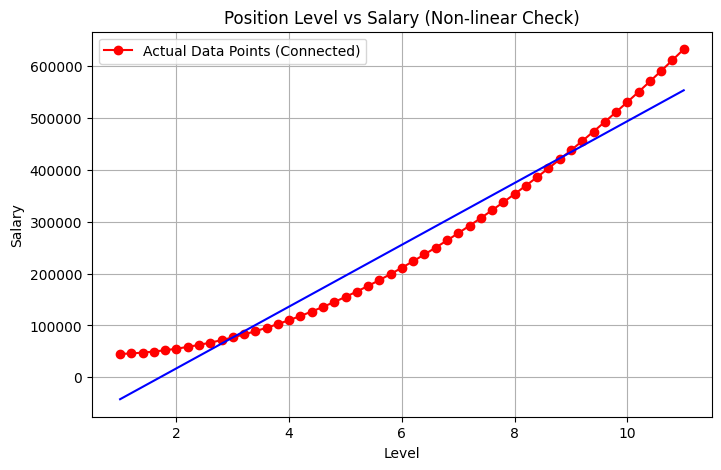

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/content/Qwen_csv_20250817_bh3eply8h.txt')

# Extract variables
X = data["Level"]
y = data["Salary"]

# Scatter + connected line plot
plt.figure(figsize=(8, 5))
plt.plot(X, y, 'o-', color="red", label="Actual Data Points (Connected)")

# Linear fit for reference
import numpy as np
coeffs = np.polyfit(X, y, deg=1)
linear_fit = np.poly1d(coeffs)
plt.plot(X, linear_fit(X), color="blue")

# Labels and title


plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Position Level vs Salary (Non-linear Check)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# **Training Polynomial model**

# **Loading Dataset**

Imports PolynomialFeatures from sklearn.preprocessing (used to create polynomial terms for non-linear regression).

Reads the CSV file "Position_Salaries (1).csv" into a Pandas DataFrame df.

Displays the first 5 rows with df.head() to check the dataset structure.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
df = pd.read_csv('/content/Qwen_csv_20250817_bh3eply8h.txt')
df.head()

,Level,Salary
0,1.0,45000
1,1.2,46115
2,1.4,47694
3,1.6,49736
4,1.8,52242


# **Train-Test-Split Data**


*   This code splits the dataset into training (80%) and testing (20%) sets, with Level as input (X) and Salary as output (y).
*   The training set is used to build the model, and the testing set is used to check its performance.






In [ ]:
from sklearn.model_selection import train_test_split
X= df[['Level']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# **This code builds a Polynomial Regression model:**



*   **PolynomialFeatures(degree=4)** → converts the input Level into polynomial features up to degree 4 (adds
𝑥
2
,
𝑥
3
,
𝑥
4
).

*   **fit_transform(X_train)** → applies this transformation to training data.
*   **transform(X_test)** → applies the same transformation to test data.


*  **LinearRegression()** → creates a regression model.

*   **fit(...)** → trains the model on the transformed training data.
















In [ ]:
from sklearn.linear_model import LinearRegression
poly_reg = PolynomialFeatures(degree = 4)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

**This line uses the trained polynomial regression model to predict salaries for the test set (X_test_poly).**

In [ ]:
y_pred = poly_model.predict(X_test_poly)

# **Performance metrics for Polynomial Regression**

**MAE (Mean Absolute Error)**: average of absolute differences between actual and predicted salaries. Lower = better.

**R² Score**: tells how well the model explains the variance in salaries. Closer to 1 = better fit.

**RMSE (Root Mean Squared Error)**: square root of average squared errors. Penalizes large errors more. Lower = better.

**MAPE (Mean Absolute Percentage Error)**: average percentage error between predictions and actuals. Lower = better.

# **Results show that the polynomial regression model (degree 4) is performing extremely well:**

**MAE** ≈ 291 → On average, predictions are only off by about 291 salary units, which is tiny compared to the salary scale (likely in thousands or lakhs).

**R²** ≈ 0.99999 → Almost a perfect fit; the model explains nearly all the variation in salaries.

**RMSE** ≈ 345 → Very low error considering the salary range, confirming predictions are very close to actual values.

**MAPE** ≈ 0.12% → The percentage error is almost negligible (<1%), meaning predictions are almost exact.

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score

mae_poly = mean_absolute_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)
rmse_poly = root_mean_squared_error(y_test, y_pred)
mape_poly = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Absolute Error:", mae_poly)
print("R² Score:", r2_poly)
print("RMSE: ", rmse_poly)
print("MAPE: ", mape_poly)

Mean Absolute Error: 291.37884638403193
R² Score: 0.9999955669785033
RMSE:  344.9437540662132
MAPE:  0.0012272442818938923


# **Visualisation of data against polynomial fit**

The plot shows that the polynomial regression model (red line) almost perfectly overlaps with the actual salary data (blue points). This confirms an excellent fit — the model accurately captures the non-linear salary growth with increasing position levels.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


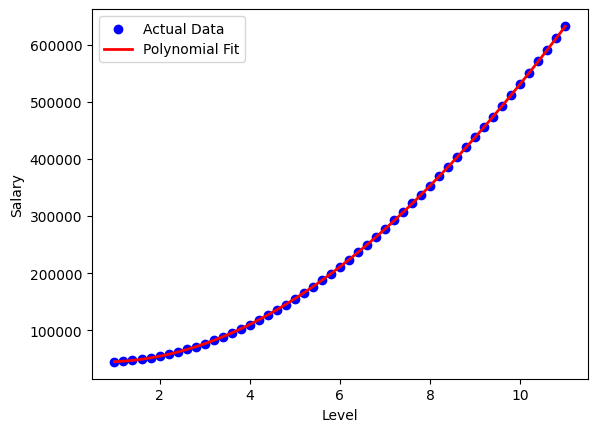

In [ ]:
import matplotlib.pyplot as plt

# Sort values for smooth plotting
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = poly_model.predict(poly_reg.transform(X_plot))

plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X_plot, y_plot, color="red", linewidth=2, label="Polynomial Fit")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()


# **Model Coefficient**

The model expresses Salary as a 4th-degree polynomial function of Level, with the listed intercept and coefficients.

Formula used by the model (degree 4 polynomial regression):

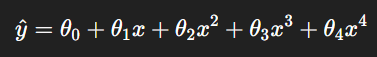

So plugging in the coeff:
y^​=48567.90 - 9655.05x + 6558.47x^2 − 63.33x^3 − 1.33x^4

In [ ]:
# Model Coefficient
intercept = poly_model.intercept_
coefficients = poly_model.coef_

print(f"Intercept (theta_0): {intercept}")
print("Coefficients:")
for i, coef in enumerate(coefficients):
    print(f"  theta_{i}: {coef}")


Intercept (theta_0): 48567.90353856134
Coefficients:
  theta_0: 0.0
  theta_1: -9655.04776715462
  theta_2: 6558.465211872665
  theta_3: -63.33279428069727
  theta_4: -1.334800016551526


# **Linear Regression performance metrics**

This metrics show a much weaker fit compared to our earlier polynomial model:



*   **MAE** ≈ 31,345 → average error is now in the tens of thousands.

*  ** R²** ≈ 0.955 → model explains about 95.5% of the variance (still decent, but not close to 1 like before).
*  ** RMSE** ≈ 34,673 → large errors are present.


*  ** MAPE** ≈ 22.3% → predictions are off by about 22% on average, which is quite high.










**Summary:** This model is not capturing the salary vs level relationship well. Compared to our degree-4 polynomial regression (which had near-perfect metrics), this one is underfitting.

In [ ]:
# Linear regression metrics
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lin)
r2 = r2_score(y_test, y_pred_lin)
rmse = root_mean_squared_error(y_test, y_pred_lin)
mape = mean_absolute_percentage_error(y_test, y_pred_lin)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
print("RMSE: ", rmse)
print("MAPE: ", mape)

Mean Absolute Error: 31344.662874783793
R² Score: 0.9552090465583705
RMSE:  34673.16772856511
MAPE:  0.22348645872033926


# **Linear vs Polynomial Regression performance metrics**

Linear regression underfits the data with high errors and only 95% accuracy, while polynomial regression (degree 4) fits almost perfectly with very low errors and 99.9% accuracy, showing that salary growth follows a non-linear trend.

In [ ]:
metrics_df = pd.DataFrame({
    "Linear Regression": {
        "MAE": mae,
        "R² Score": r2,
        "RMSE": rmse,
        "MAPE": mape
    },
    "Polynomial Regression": {
        "MAE": mae_poly,
        "R² Score": r2_poly,
        "RMSE": rmse_poly,
        "MAPE": mape_poly
    }
})

# Transpose for a nicer view
metrics_df = metrics_df.T
# print(metrics_df)

# Or display as a proper table in Colab
from IPython.display import display
display(metrics_df)


,MAE,R² Score,RMSE,MAPE
Linear Regression,31344.662875,0.955209,34673.167729,0.223486
Polynomial Regression,291.378846,0.999996,344.943754,0.001227


# **Visualisation of linear vr polynomial regression**

The plot compares Linear Regression (green line) and Polynomial Regression (red line) against the actual data (blue points). Linear regression fails to follow the curved salary trend, while polynomial regression closely matches the actual data, proving it models the non-linear relationship much better.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


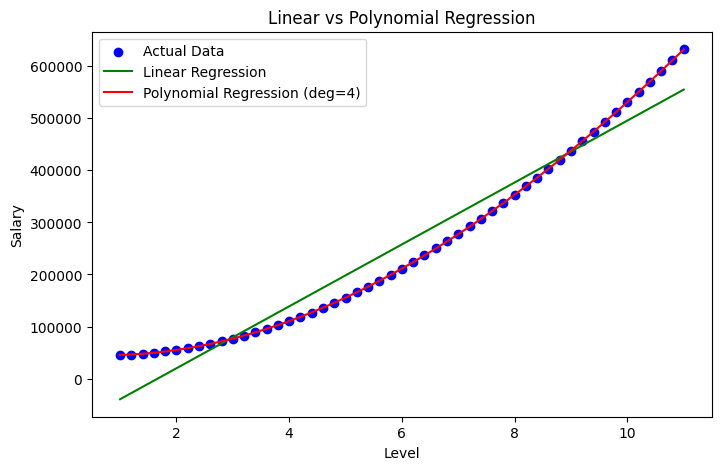

In [ ]:
# Grid for smooth plotting
X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# Predictions
y_lin_plot = lin_model.predict(X_grid)
y_poly_plot = poly_model.predict(poly_reg.transform(X_grid))

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X_grid, y_lin_plot, color="green", label="Linear Regression")
plt.plot(X_grid, y_poly_plot, color="red", label="Polynomial Regression (deg=4)")
plt.legend()
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Linear vs Polynomial Regression")
plt.show()
